# Feature-Level Views

This notebook focuses on feature-level visual analysis for the S&P 500 bull/bear regime project.

The goals are to:

- inspect how technical and macro features behave over time
- compare feature distributions across bull and bear regimes
- identify features that separate regimes well
- save report-ready figures for later use

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [41]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / "data" / "labeled_dataset.csv"
FIGURES_DIR = REPO_ROOT / "reports" / "figures" / "feature_level_views"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

technical_features = [
    "Return",
    "Return_5d",
    "Return_20d",
    "Return_Smooth",
    "RSI_14",
    "MACD_Line",
    "MACD_Signal",
    "MACD_Hist",
    "Drawdown",
    "VIX",
    "VIX_Change",
    "VIX_Change_5d",
]

macro_features = [
    "GDP",
    "Core_Inflation",
    "Unemployment",
    "M2",
    "GDP_YoY",
    "Core_Inflation_YoY",
    "M2_YoY",
]

selected_features = [
    "Return_20d",
    "RSI_14",
    "MACD_Hist",
    "Drawdown",
    "VIX",
    "GDP_YoY",
    "Core_Inflation_YoY",
    "Unemployment",
]

df[["Date", "regime", *selected_features]].head()

,Date,regime,Return_20d,RSI_14,MACD_Hist,Drawdown,VIX,GDP_YoY,Core_Inflation_YoY,Unemployment
0,1994-01-27,bear,0.017945,63.627969,-0.061014,0.000000,10.30,0.034307,0.022466,6.6
1,1994-01-28,bear,0.026262,66.263983,0.177433,0.000000,9.94,0.034307,0.020516,6.6
2,1994-01-31,bear,0.034741,70.345767,0.484681,0.000000,10.63,0.034307,0.020516,6.6
3,1994-02-01,bear,0.027265,64.590426,0.505137,-0.004132,10.65,0.034307,0.022728,6.6
4,1994-02-02,bear,0.030906,67.966058,0.622496,0.000000,10.61,0.034307,0.022728,6.6


## Dataset Overview

In [43]:
print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("\nRegime counts:")
print(df["regime"].value_counts(dropna=False))
print("\nMissing values in selected features:")
print(df[selected_features].isna().sum().sort_values(ascending=False))

Shape: (8066, 28)
Date range: 1994-01-27 to 2026-02-13

Regime counts:
regime
bull    5061
bear    3005
Name: count, dtype: int64

Missing values in selected features:
Return_20d            0
RSI_14                0
MACD_Hist             0
Drawdown              0
VIX                   0
GDP_YoY               0
Core_Inflation_YoY    0
Unemployment          0
dtype: int64


## Helper Functions

In [44]:
REGIME_COLORS = {"bull": "#2a9d8f", "bear": "#d62828"}


def save_current_figure(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_feature_by_regime(feature: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.histplot(
        data=df,
        x=feature,
        hue="regime",
        bins=40,
        stat="density",
        common_norm=False,
        palette=REGIME_COLORS,
        alpha=0.4,
        ax=axes[0],
    )
    axes[0].set_title(f"Distribution of {feature} by Regime")

    sns.boxplot(
        data=df,
        x="regime",
        y=feature,
        hue="regime",
        order=["bull", "bear"],
        palette=REGIME_COLORS,
        dodge=False,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title(f"{feature} by Regime")
    axes[1].set_xlabel("")

    save_current_figure(f"distribution_{feature.lower()}")


def plot_time_series(feature: str, rolling_window: int = 60) -> None:
    plot_df = df[["Date", feature, "regime"]].dropna().copy()
    plot_df[f"{feature}_rolling"] = plot_df[feature].rolling(rolling_window).mean()

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(plot_df["Date"], plot_df[feature], color="#457b9d", alpha=0.35, linewidth=1, label=feature)
    ax.plot(
        plot_df["Date"],
        plot_df[f"{feature}_rolling"],
        color="#1d3557",
        linewidth=2.2,
        label=f"{rolling_window}-day rolling mean",
    )
    ax.set_title(f"{feature} Over Time")
    ax.legend(frameon=False)

    save_current_figure(f"timeseries_{feature.lower()}")


## Regime Balance

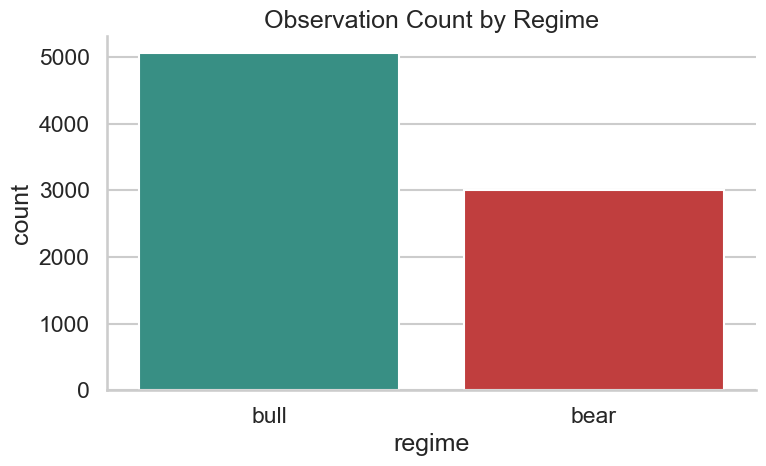

In [45]:
regime_counts = df["regime"].value_counts().rename_axis("regime").reset_index(name="count")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=regime_counts,
    x="regime",
    y="count",
    hue="regime",
    palette=REGIME_COLORS,
    legend=False,
)
plt.title("Observation Count by Regime")
save_current_figure("regime_counts")

## Feature Distributions by Regime

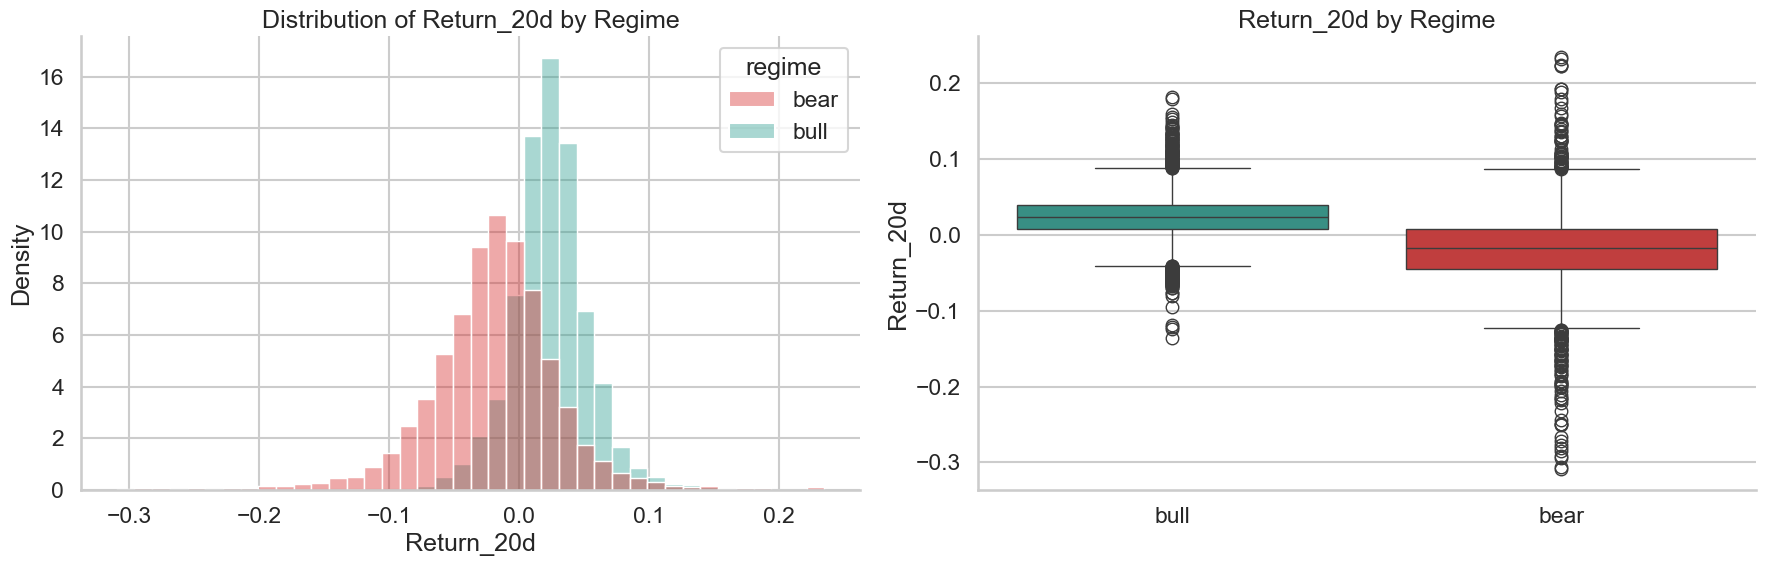

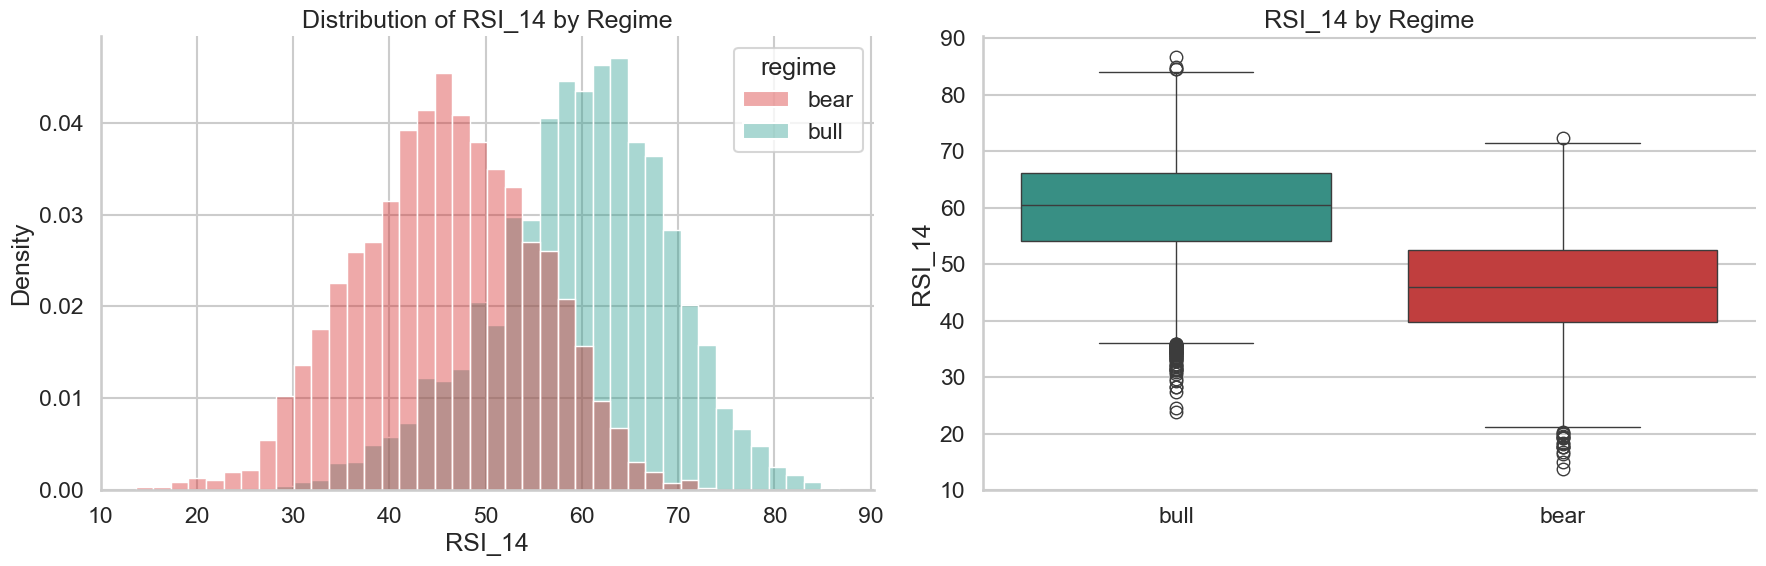

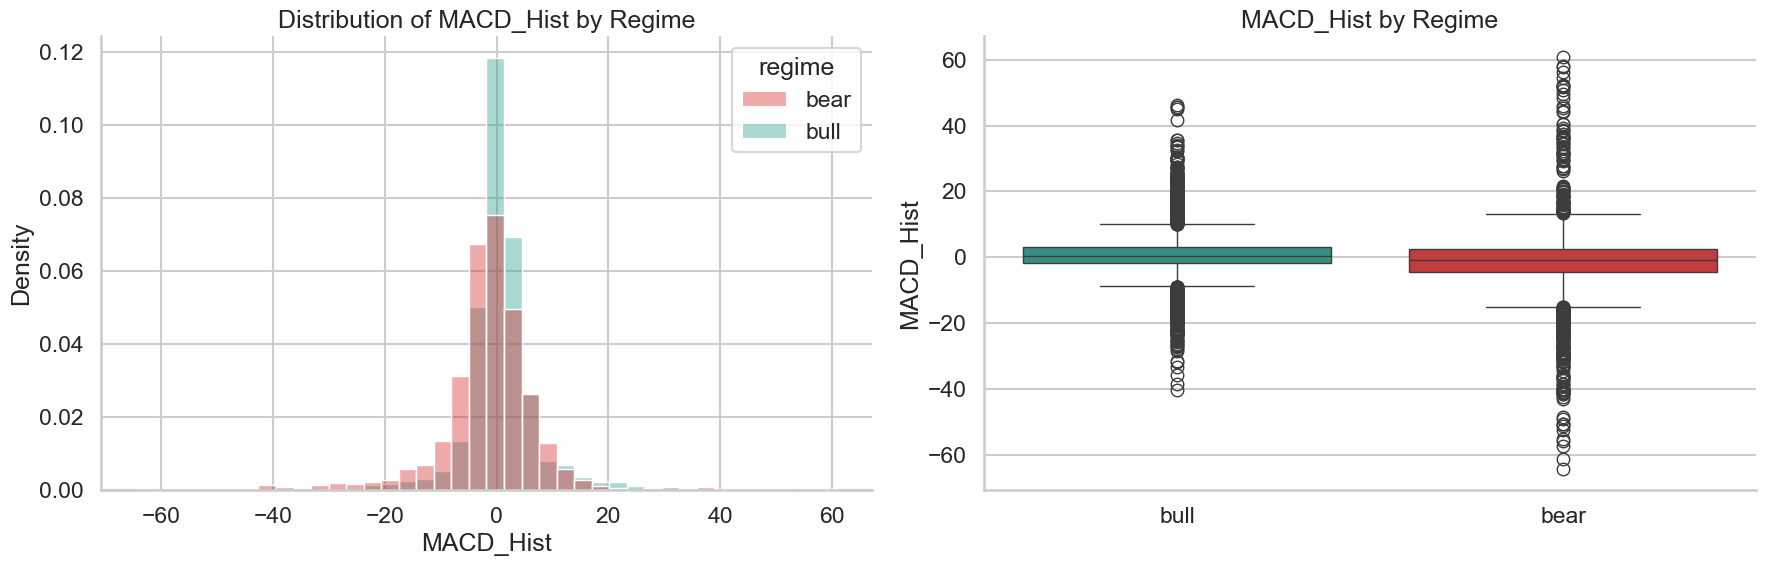

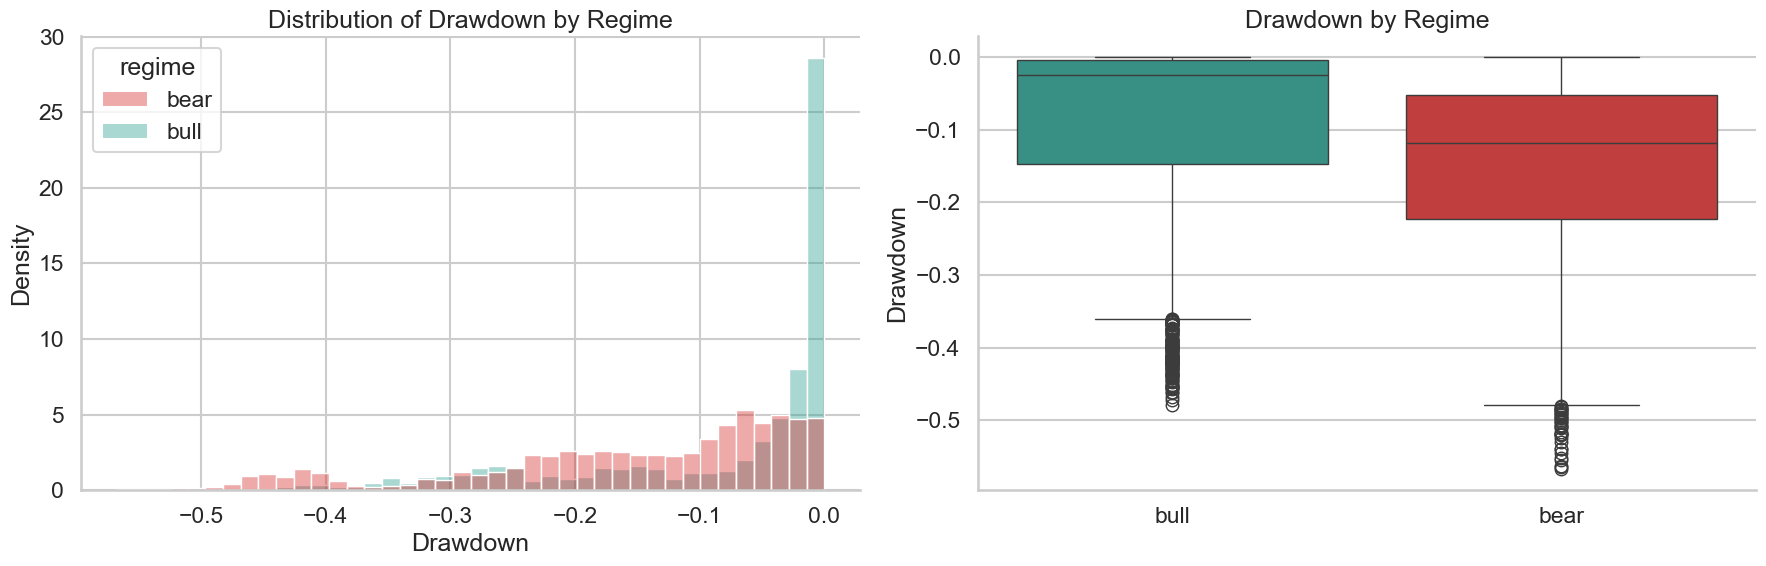

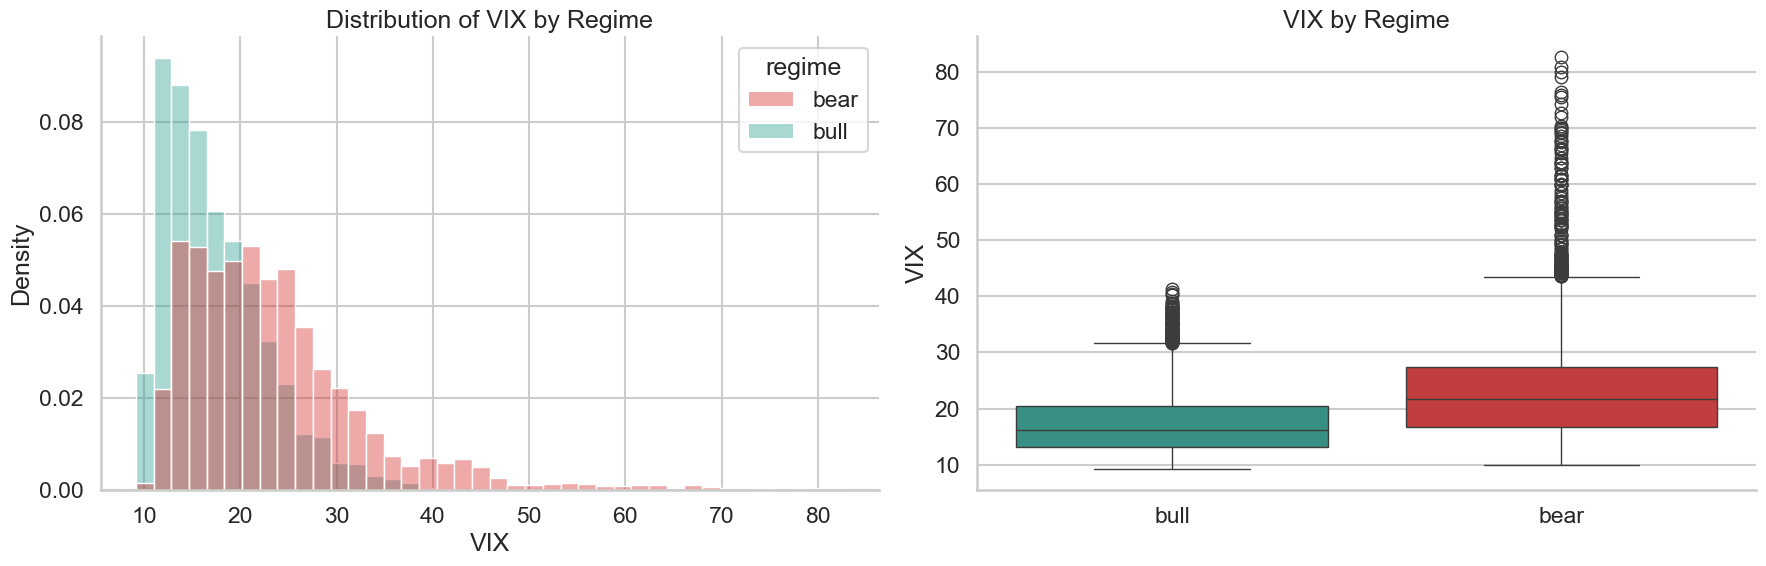

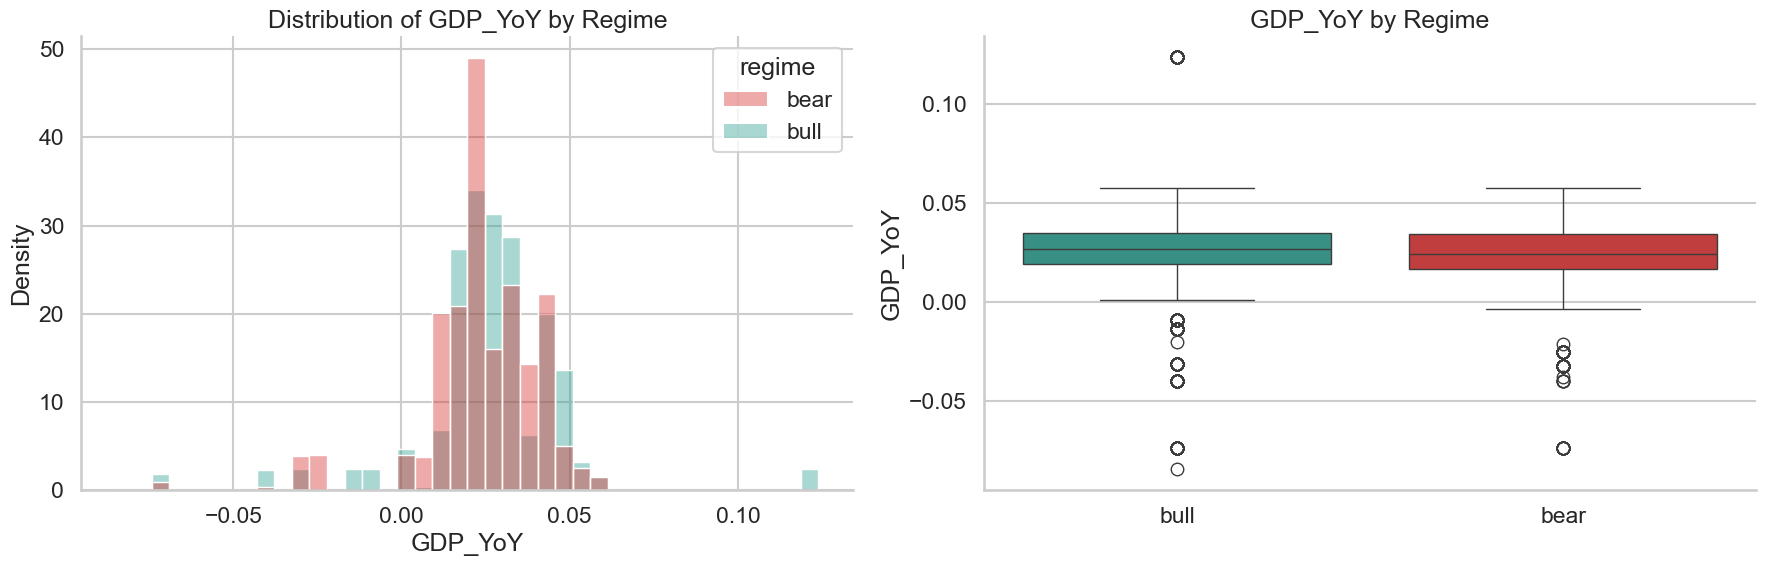

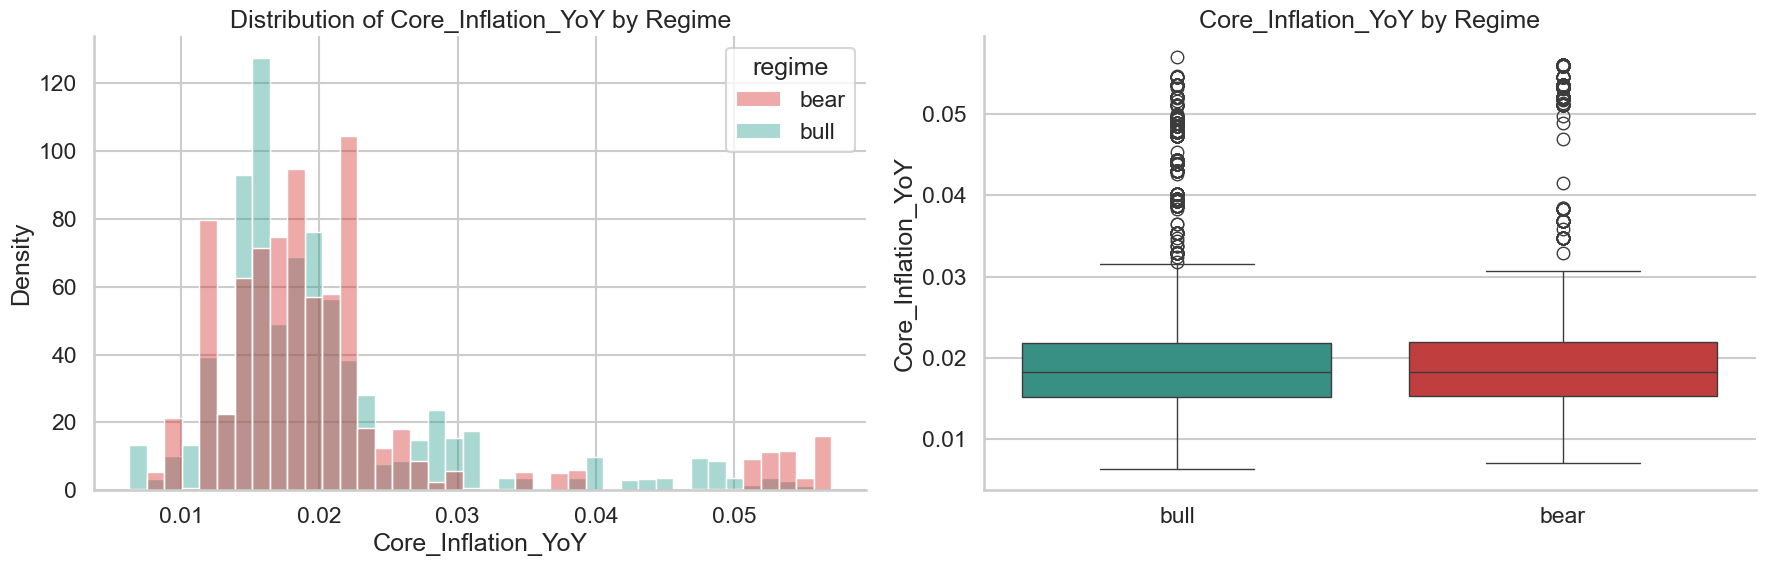

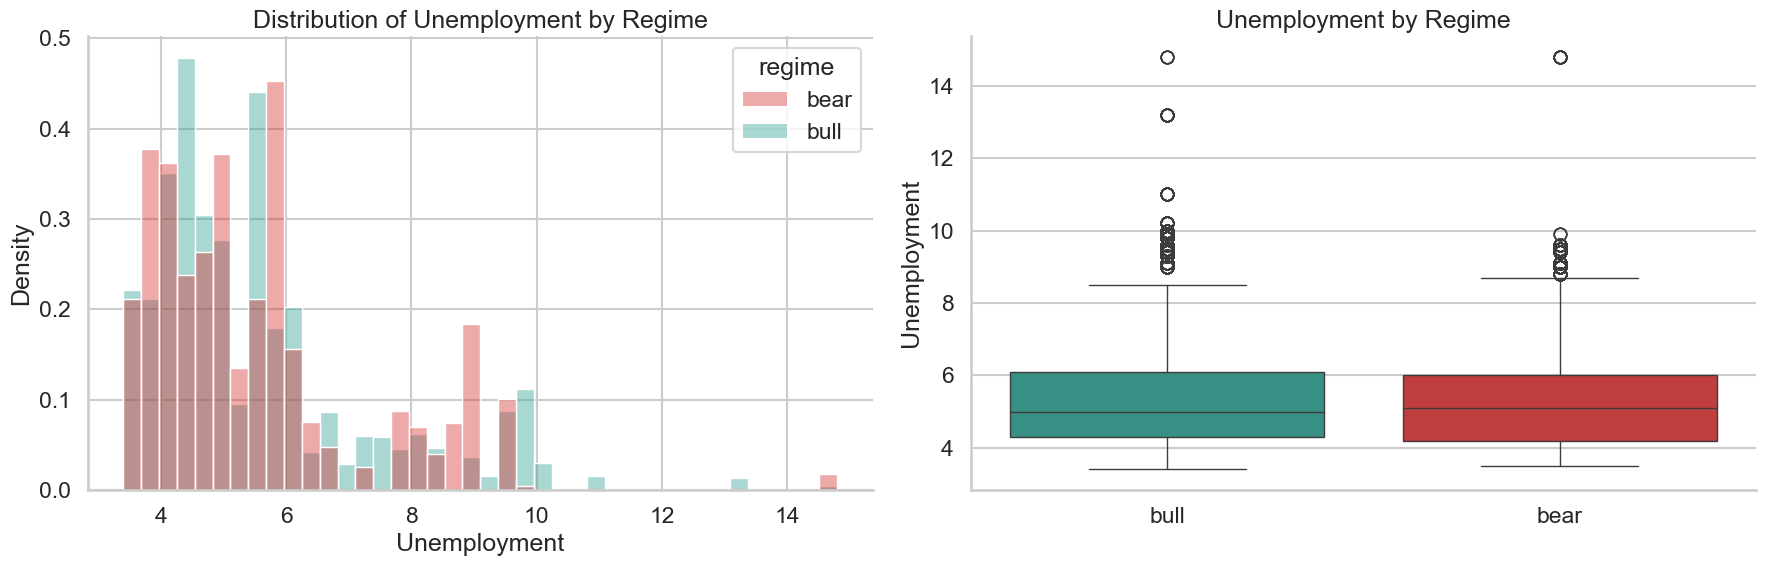

In [46]:
for feature in selected_features:
    plot_feature_by_regime(feature)

## Time-Series Views for Key Features

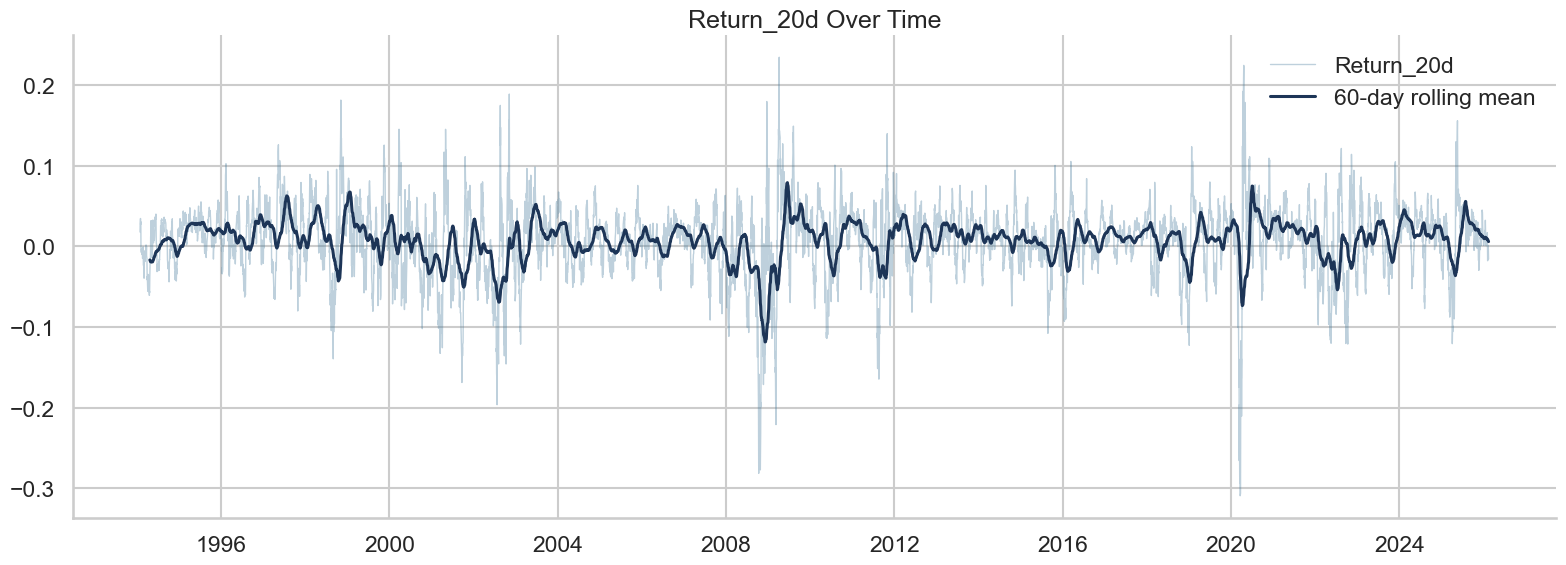

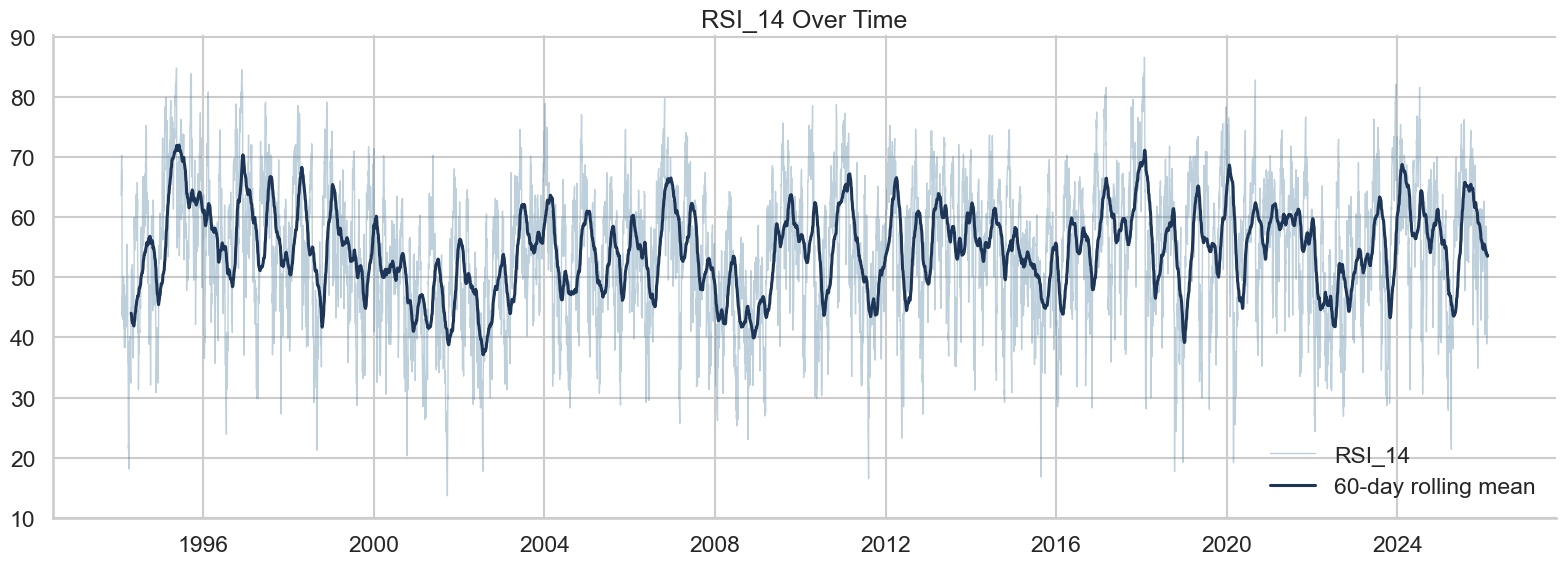

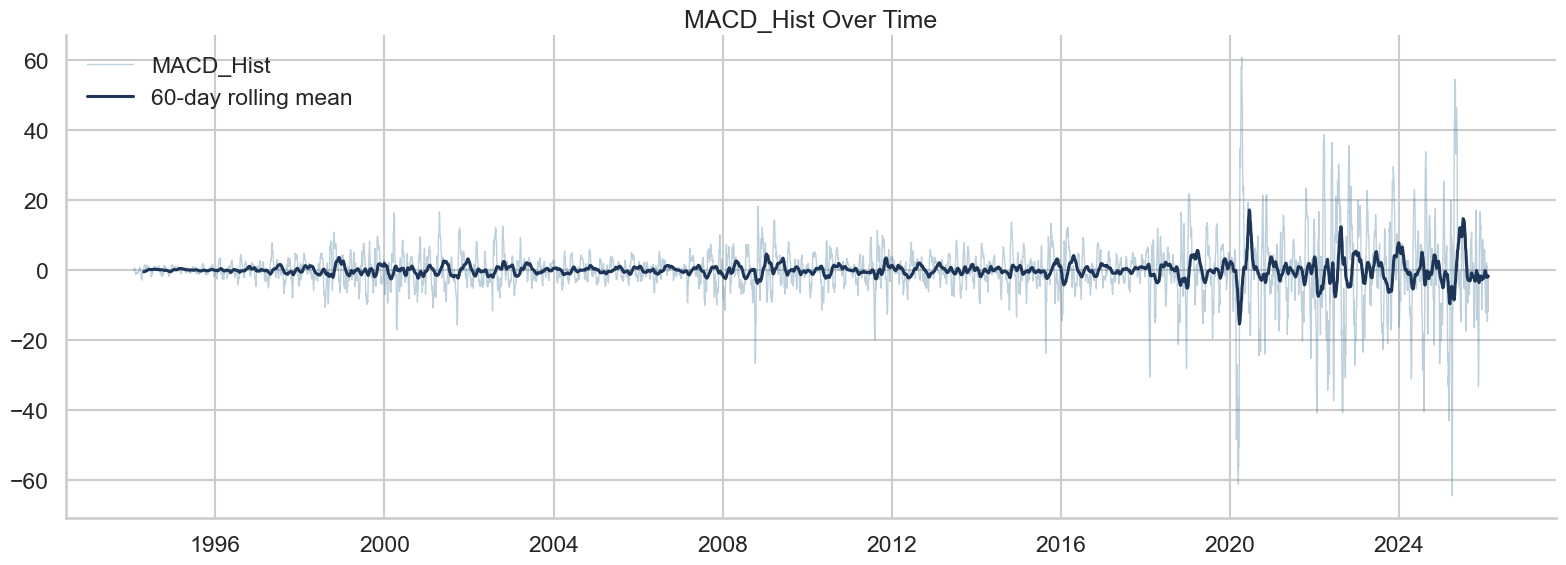

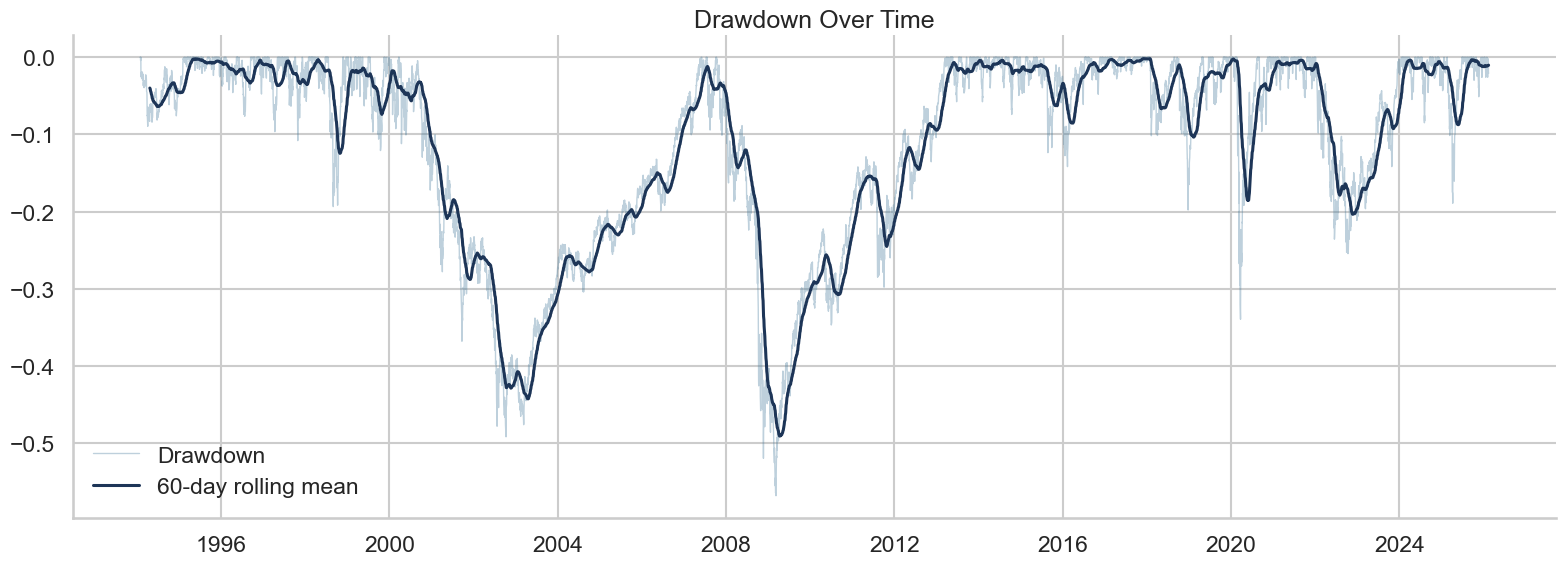

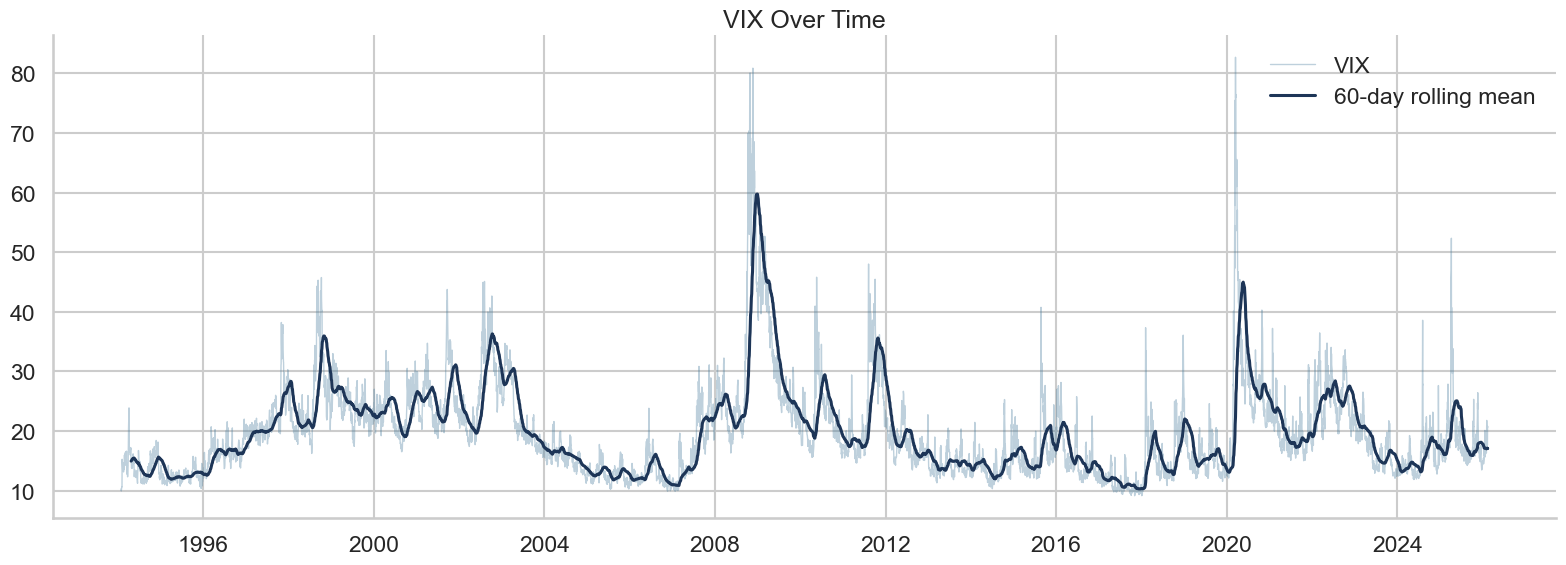

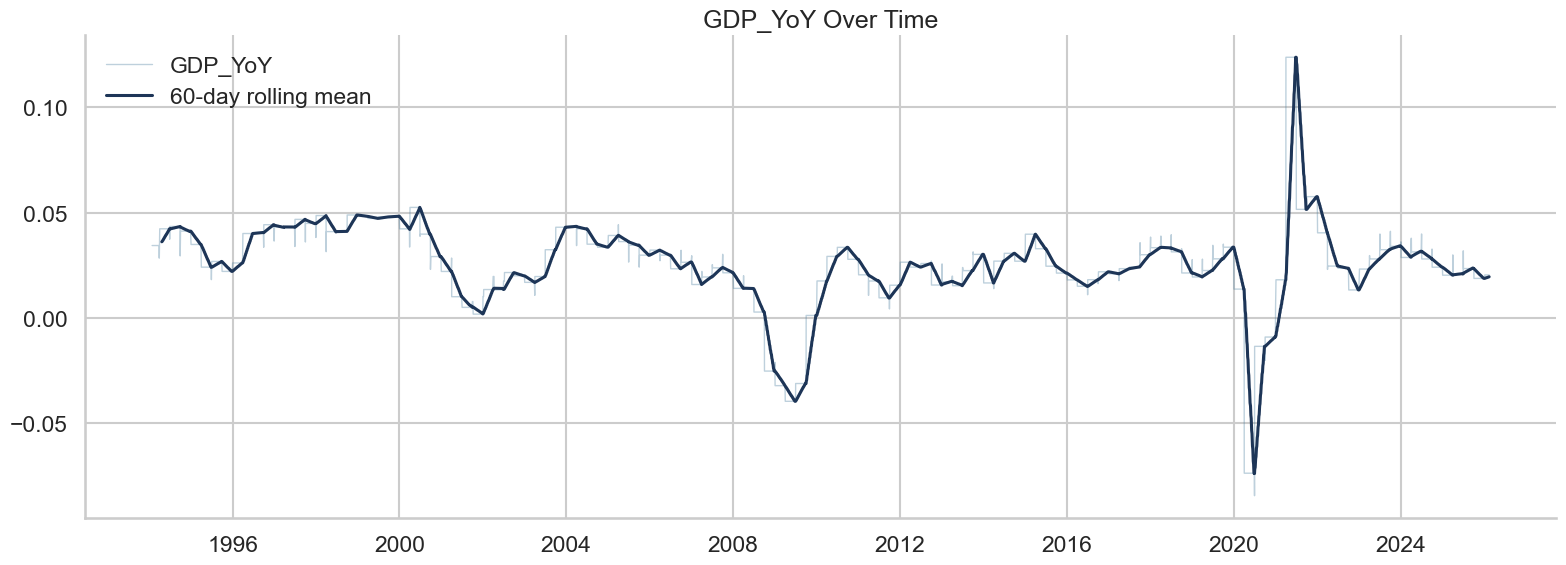

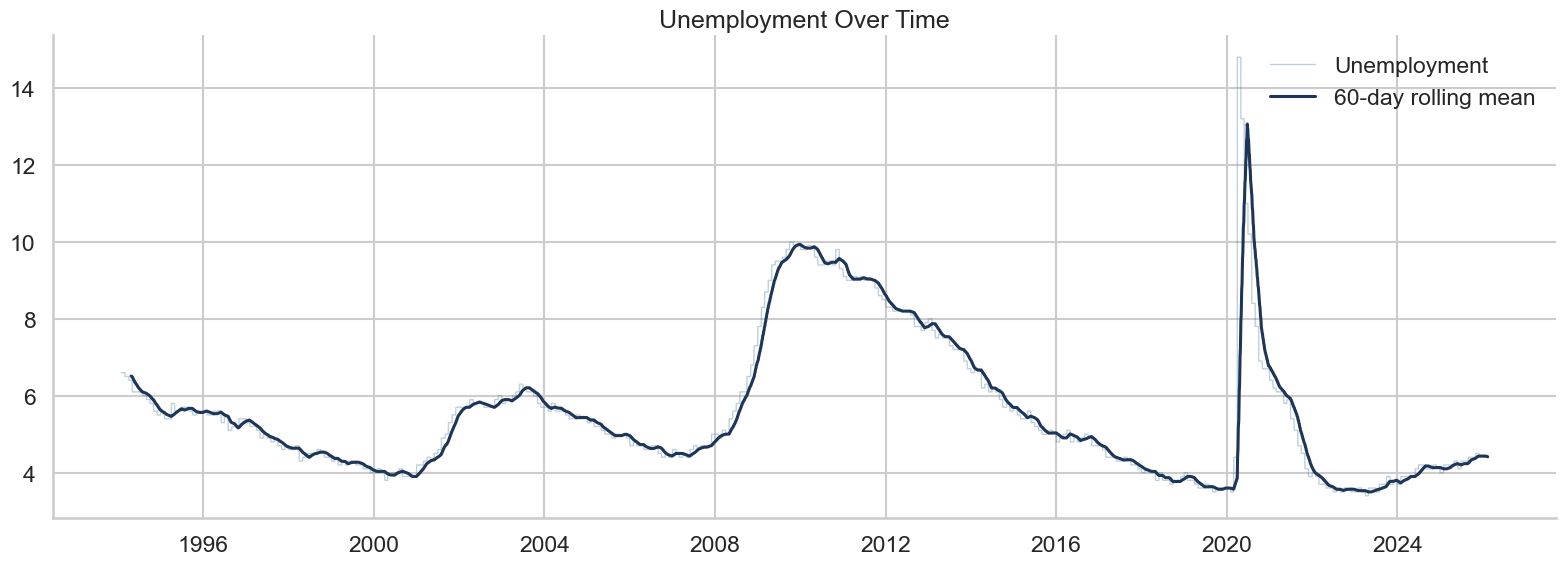

In [47]:
for feature in ["Return_20d", "RSI_14", "MACD_Hist", "Drawdown", "VIX", "GDP_YoY", "Unemployment"]:
    plot_time_series(feature)

## Correlation Heatmap

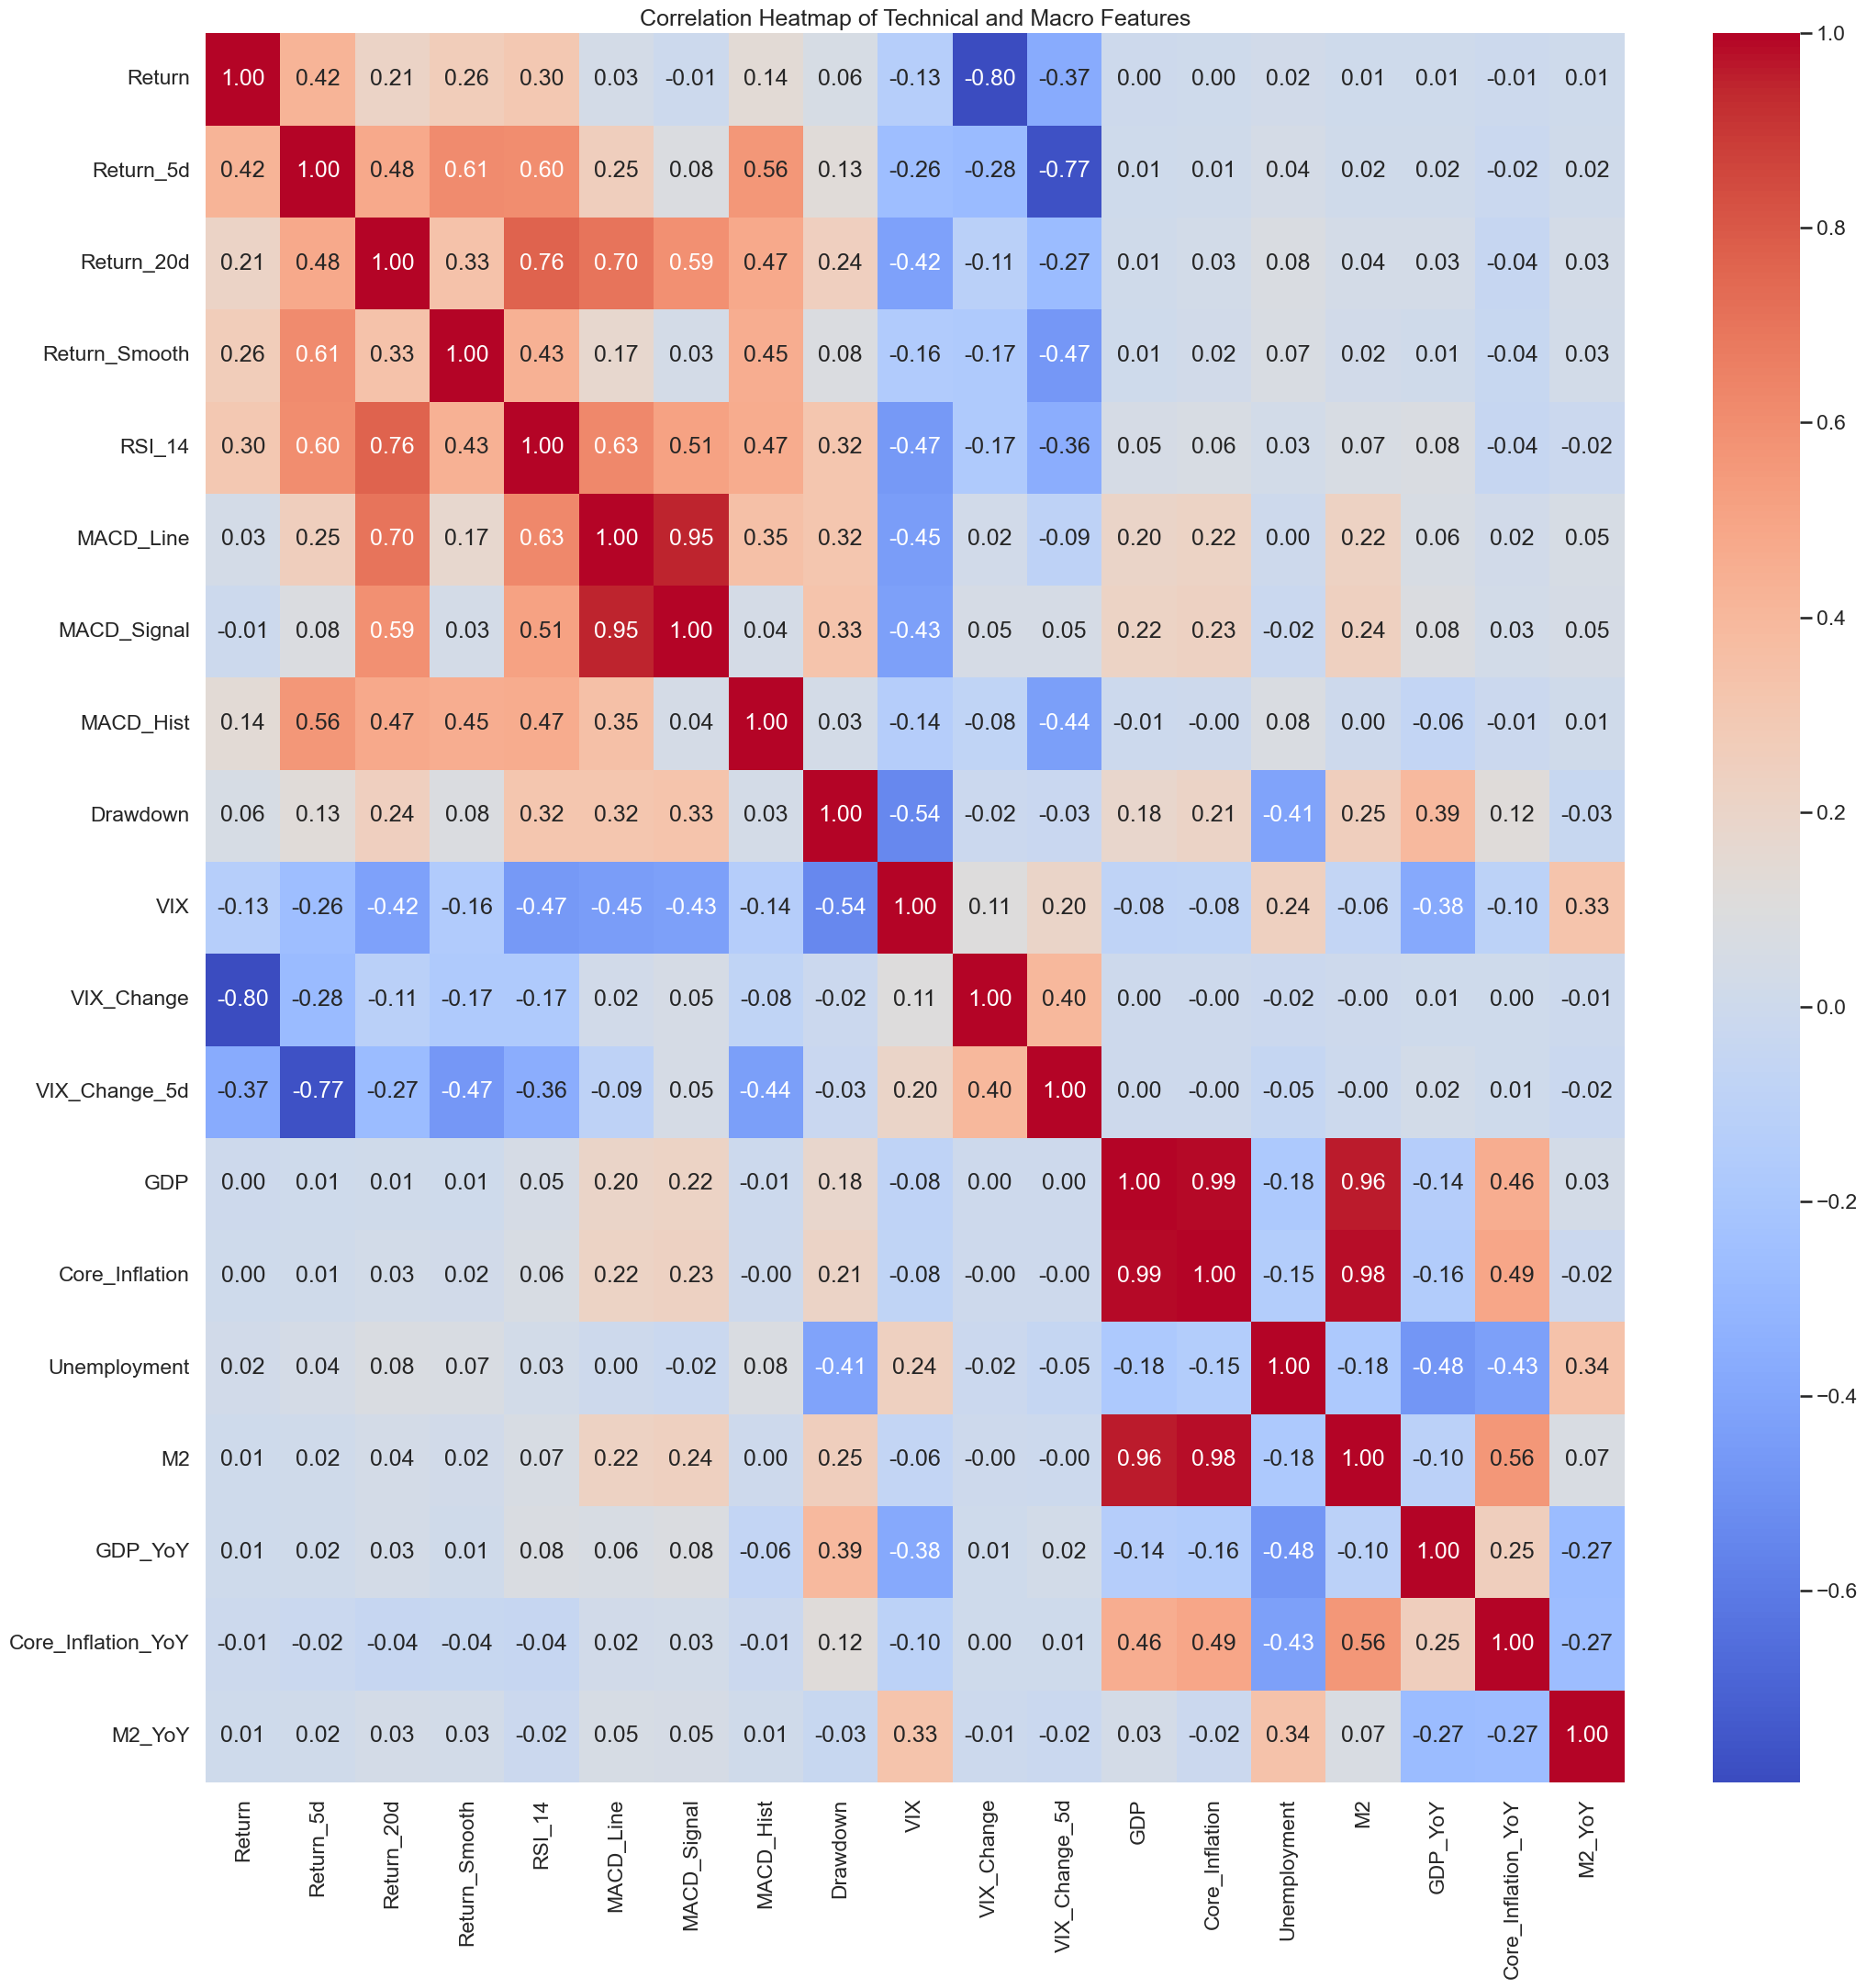

In [50]:
heatmap_features = technical_features + macro_features
corr = df[heatmap_features].corr()

plt.figure(figsize=(22, 22))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Technical and Macro Features")
save_current_figure("correlation_heatmap")

## Summary Statistics by Regime

In [49]:
summary = df.groupby("regime")[selected_features].agg(["mean", "median", "std"]).round(3)
summary

Return_20d                RSI_14                MACD_Hist         \
             mean median    std    mean  median    std      mean median   
regime                                                                    
bear       -0.020 -0.018  0.052  45.882  45.917  9.236    -1.310 -0.895   
bull        0.024  0.024  0.030  59.709  60.418  9.249     0.782  0.383   

               Drawdown  ...    VIX GDP_YoY               Core_Inflation_YoY  \
           std     mean  ...    std    mean median    std               mean   
regime                   ...                                                   
bear    10.075   -0.155  ...  9.909   0.024  0.024  0.018              0.021   
bull     6.466   -0.085  ...  5.405   0.027  0.027  0.022              0.020   

                     Unemployment                
       median    std         mean median    std  
regime                                           
bear    0.018  0.010        5.536    5.1  1.769  
bull    0.018  0.009        5.540    5.0  1.792  

[2 rows x 24 columns]